In [2]:
%cd ..

/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce


In [3]:
!pip install --upgrade gensim

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import pickle
import torch

from Code.Evaluate.Metrics import score_all, get_tw_embeddings
from Code.TNTM.TNTM_bow import TNTM_bow

[nltk_data] Downloading package brown to /Users/stan/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/stan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


current device: cpu
current device: cpu


In [6]:
with open("Data/DataOctis/octis_dataset_20ng.pickle", "rb") as file:
    octis_dataset = pickle.load(file)

corpus = octis_dataset.get_corpus()

In [7]:
tw_emb = get_tw_embeddings(octis_dataset)

100%|██████████| 48018/48018 [04:32<00:00, 176.13it/s]


In [19]:
with open(
    "/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Data/DataOctis/cleaned_embedding_df_20ng_BERT.pickle",
    "rb",
) as f:
    embedding_df = pickle.load(f)

In [20]:
embedding_df.sort_values(by="word", inplace=True)

In [21]:
embedding_ten_lis = []

for i in range(len(embedding_df)):
    embedding_ten_lis.append(embedding_df["embedding"].iloc[i])

In [22]:
embedding_df.sort_values(by="word", inplace=True)
embedding_ten_lis = []

embedded_words = embedding_df.index.tolist()

for i in range(len(embedding_df)):
    embedding_ten_lis.append(embedding_df["embedding"].iloc[i])
embedding_ten = torch.stack(embedding_ten_lis)

In [23]:
vocab = embedded_words
vocab_set = set(vocab)
corpus = [
    [word for word in doc if word in vocab_set] for doc in octis_dataset.get_corpus()
]

In [24]:
model = TNTM_bow(
    n_topics=10,
    save_path="/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/SavedResults/model_v2.pth",
    n_dims=11,
    n_hidden_units=200,
    n_encoder_layers=3,
    enc_lr=1e-4,
    dec_lr=1e-3,
    n_epochs=0,
    # batch_size = 128,
    batch_size=256,
    dropout_rate_encoder=0.3,
    prior_variance=0.995,
    prior_mean=None,
    n_topwords=200,
    device="cpu",
    validation_set_size=0.2,
    early_stopping=True,
    n_epochs_early_stopping=10,
    return_embeddings=False,
    eps=1e-4,
    umap_hyperparams={"n_neighbors": 15, "min_dist": 0.0},
    return_losses=True,
)

In [25]:
res_all = model.fit(corpus=corpus, vocab=vocab, embeddings=embedding_ten)

16309it [00:02, 6264.54it/s]
/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  log

In [26]:
len(corpus)

16309

In [27]:
# remove all documents shorter than 10 words
corpus = [doc for doc in corpus if len(doc) >= 10]

In [28]:
octis_dataset._Dataset__corpus = corpus
octis_dataset._Dataset__vocab = vocab

In [29]:
evaluation_result = score_all(
    dataset=octis_dataset,
    tw_emb=tw_emb,
    n_words=10,
    result={"topics": res_all[0], "topic-word-matrix": res_all[1]},
)

[==================================================] 100.0% 1662.8/1662.8MB downloaded


100%|██████████| 5/5 [00:04<00:00,  1.15it/s]


In [30]:
res_all

(array([['hmmm', 'br', 'nh', ..., 'girl', 'glad', 'less'],
        ['pure', 'ideal', 'simple', ..., 'nyx', 'code', 'zuma'],
        ['career', 'hit', 'strike', ..., 'jay', 'janet', 'zuma'],
        ...,
        ['controller', 'remote', 'shell', ..., 'lawrence', 'license',
         'zuma'],
        ['frank', 'watson', 'david', ..., 'forever', 'following', 'zuma'],
        ['community', 'nation', 'crowd', ..., 'killing', 'll', 'zuma']],
       dtype='<U14'),
 array([[1.07259462e+09, 1.05133728e+09, 9.07814528e+08, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.50570320e+08, 1.27028696e+08, 1.12089384e+08, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [9.51220800e+06, 9.30248000e+06, 8.64949100e+06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [8.99422400e+07, 7.92253680e+07, 7.22992960e+07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [9.93249772e+10, 9.40691374e+10, 7.633

In [32]:
def eval_model_n_topics(n_topics: int):
    model = TNTM_bow(
        n_topics=n_topics,
        save_path="../../msc/SavedResults/model_v2.pth",
        n_dims=11,
        n_hidden_units=200,
        n_encoder_layers=3,
        enc_lr=1e-4,
        dec_lr=1e-3,
        n_epochs=0,
        # batch_size = 128,
        batch_size=256,
        dropout_rate_encoder=0.3,
        prior_variance=0.995,
        prior_mean=None,
        n_topwords=200,
        device=None,
        validation_set_size=0.2,
        early_stopping=True,
        n_epochs_early_stopping=10,
        return_embeddings=False,
        eps=1e-4,
        umap_hyperparams={"n_neighbors": 15, "min_dist": 0.0},
        return_losses=True,
    )

    res_all = model.fit(corpus=corpus, vocab=vocab, embeddings=embedding_ten)

    evaluation_result = score_all(
        dataset=octis_dataset,
        tw_emb=tw_emb,
        n_words=10,
        result={"topics": res_all[0], "topic-word-matrix": res_all[1]},
    )

    return evaluation_result

In [34]:
# evaluate different number of topics
from tqdm import tqdm

# n_topics = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
n_topics = [5, 10, 15]
n_iter = 3

results = {}

for m in range(n_iter):
    for n in tqdm(n_topics):
        results[n] = results.get(n, []) + [eval_model_n_topics(n)]

results

13459it [00:03, 3561.67it/s]?, ?it/s]
/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTenso

{5: [{'NPMI': -0.10954181584605456,
   'WE_CO_PW': 0.016989667945437957,
   'Embedding_Coherence': 0.3187064230442047,
   'WESS': 0.44903934863347816,
   'Topic Diversity': 1.0},
  {'NPMI': -0.16138700447399038,
   'WE_CO_PW': 0.035971870422363286,
   'Embedding_Coherence': 0.30632007122039795,
   'WESS': 0.4630449170902485,
   'Topic Diversity': 1.0},
  {'NPMI': -0.14543160095206079,
   'WE_CO_PW': 0.07575435241063436,
   'Embedding_Coherence': 0.27837536334991453,
   'WESS': 0.4916461509909734,
   'Topic Diversity': 1.0}],
 10: [{'NPMI': -0.1252320588611439,
   'WE_CO_PW': 0.04211431463559468,
   'Embedding_Coherence': 0.3171433970332146,
   'WESS': 0.46570024069070287,
   'Topic Diversity': 1.0},
  {'NPMI': -0.10929708164637686,
   'WE_CO_PW': 0.13080225560400222,
   'Embedding_Coherence': 0.3022744134068489,
   'WESS': 0.4379367595828985,
   'Topic Diversity': 1.0},
  {'NPMI': -0.1691978008856435,
   'WE_CO_PW': 0.06857113705741034,
   'Embedding_Coherence': 0.2982053607702255,
   

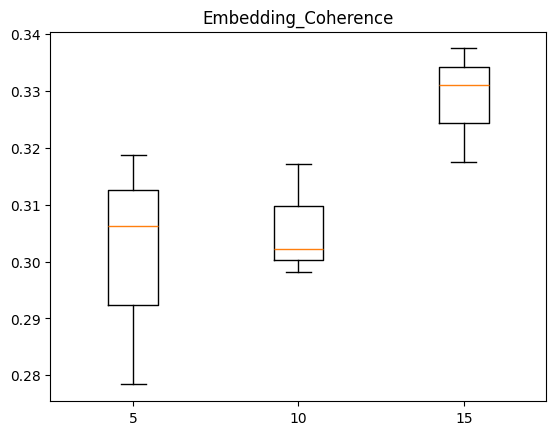

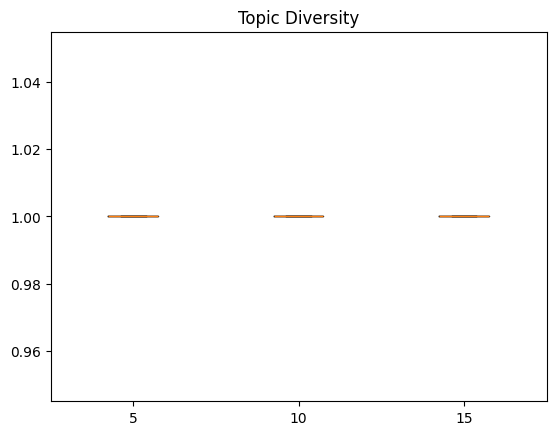

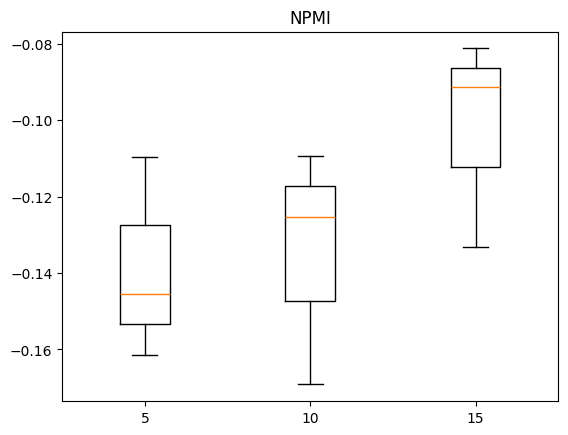

KeyError: 'Perplextiy'

In [35]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Embedding_Coherence", "Topic Diversity", "NPMI", "Perplextiy"]

# make a boxplot for each metric and each number of topics

for metric in metrics:
    data = []
    for n in n_topics:
        data.append([res[metric] for res in results[n]])
    plt.boxplot(data)
    plt.title(metric)
    plt.xticks(np.arange(len(n_topics)) + 1, n_topics)
    plt.show()


# save results